In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\evija\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# metadata
print(breast_cancer_wisconsin_diagnostic.metadata)

# variable information
print(breast_cancer_wisconsin_diagnostic.variables)


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [3]:
#Null vals
X.isnull().sum()

radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
dtype: int64

In [4]:
y.isnull().sum()

Diagnosis    0
dtype: int64

In [5]:
X

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [6]:
#Encoding class labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y.values.ravel())
print(np.unique(y_encoded))

[0 1]


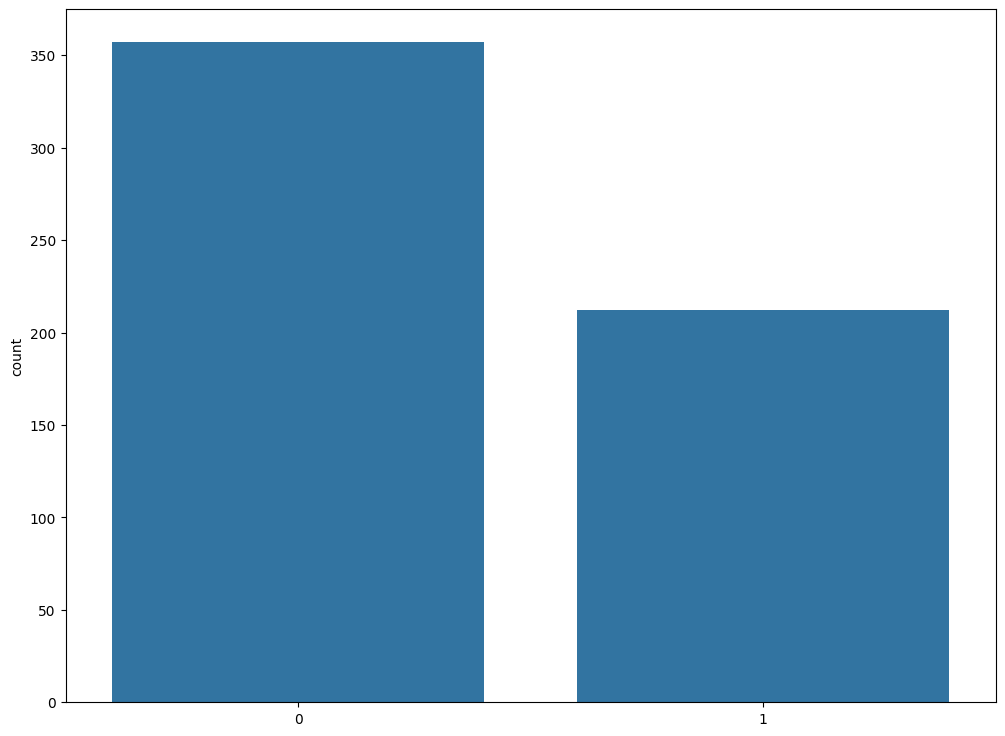

In [7]:
#Class distribution

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,9))
y_series = pd.Series(y_encoded)
y_series.value_counts()
sns.countplot(x = y_encoded)
plt.show()

In [8]:
X.shape

(569, 30)

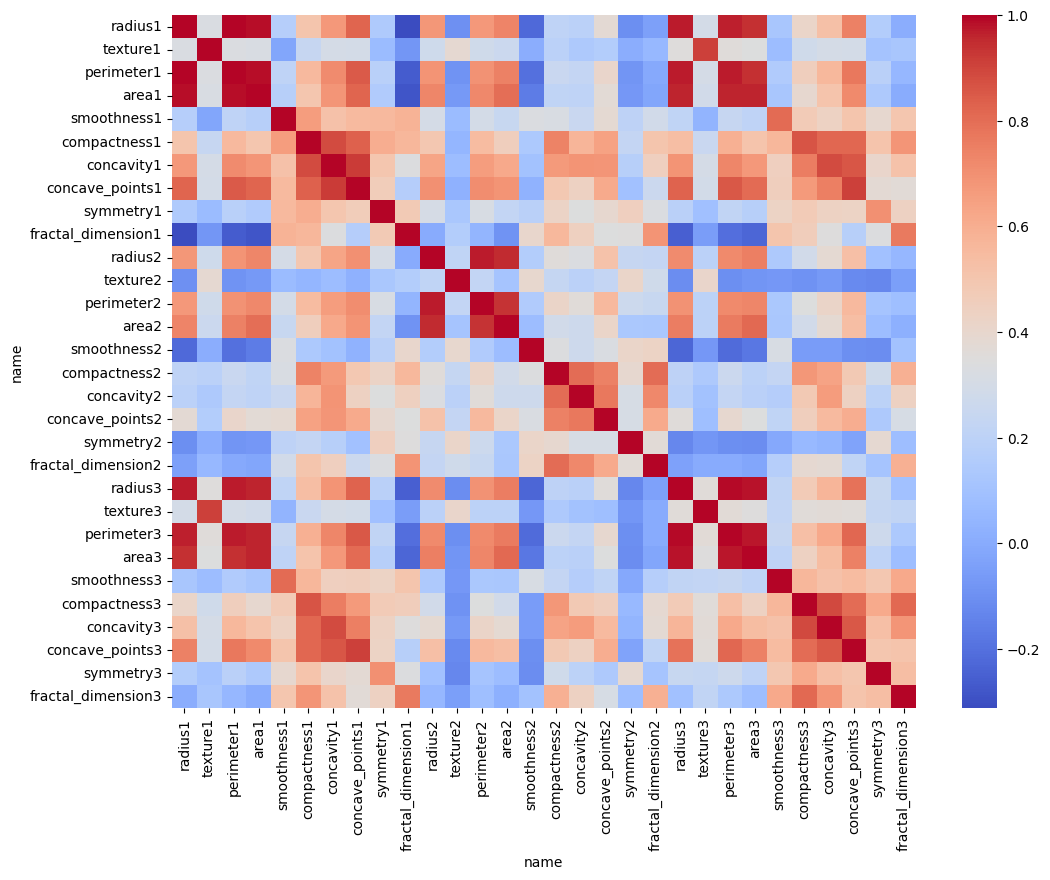

In [9]:
#Correlation analysis

X_df = pd.DataFrame(X,columns = breast_cancer_wisconsin_diagnostic.variables['name'][2:]) #im[
plt.figure(figsize=(12,9))
sns.heatmap(X_df.corr(),cmap='coolwarm')
plt.show()


In [10]:
#Split ds
from sklearn.model_selection import train_test_split
#imp

X_train,X_test,y_train,y_test = train_test_split(X,y_encoded,test_size = 0.2,random_state = 42,stratify = y_encoded)
print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [11]:
#Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report
dt = DecisionTreeClassifier(random_state = 42)
dt.fit(X_train,y_train)
dt_pred = dt.predict(X_test)
print("Accuracy:",accuracy_score(y_test,dt_pred))
print("Classification Report:",classification_report(y_test,dt_pred))


Accuracy: 0.9298245614035088
Classification Report:               precision    recall  f1-score   support

           0       0.94      0.94      0.94        72
           1       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [12]:
param_grid = {
    "max_depth":[None,5,10,20,30],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "criterion":["gini","entropy"],
    "max_features":[None,"sqrt","log2"]
}

In [13]:
from sklearn.model_selection import GridSearchCV

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),param_grid = param_grid,cv = 5,scoring = ['accuracy','f1'],n_jobs = -1,refit="accuracy")
grid_dt.fit(X_train,y_train)

results = grid_dt.cv_results_
print(results)

{'mean_fit_time': array([0.03096204, 0.03102107, 0.02902532, 0.02755442, 0.02536144,
       0.02688484, 0.02769399, 0.02619753, 0.02602944, 0.01459332,
       0.01399059, 0.01204453, 0.01078682, 0.00941939, 0.01263909,
       0.01267695, 0.01449337, 0.0134295 , 0.01133213, 0.01333127,
       0.01396694, 0.01373143, 0.0135551 , 0.01366162, 0.01232047,
       0.01382065, 0.01353574, 0.03966107, 0.04331465, 0.03484778,
       0.03460479, 0.02694659, 0.02475247, 0.02269034, 0.02176261,
       0.02355356, 0.01284075, 0.01448126, 0.01476412, 0.01561098,
       0.0127861 , 0.01257782, 0.01535959, 0.01375871, 0.01681824,
       0.01178288, 0.01258035, 0.01057954, 0.01156125, 0.01375823,
       0.01123376, 0.0139606 , 0.01491089, 0.01290107, 0.02514076,
       0.02266946, 0.02657342, 0.02448096, 0.02098446, 0.02594891,
       0.02833161, 0.02505159, 0.0270937 , 0.01426835, 0.01276517,
       0.0139524 , 0.01272945, 0.01413913, 0.01537657, 0.01414676,
       0.01650987, 0.01411452, 0.01722503, 0

In [18]:
table1 = pd.DataFrame(
    {
        "Criterion":[p['criterion'] for p in results['params']],
        "Max Depth":[p['max_depth'] for p in results['params']],
        "Avg CV Accuracy %":results['mean_test_accuracy']*100,
        "Avg F1 score":results['mean_test_f1']
    }
)

table1_sorted = table1.sort_values(by= "Avg CV Accuracy %",ascending =False) 
table1_sorted.head()

,Criterion,Max Depth,Avg CV Accuracy %,Avg F1 score
220,entropy,20.0,94.725275,0.929724
193,entropy,10.0,94.725275,0.929724
247,entropy,30.0,94.725275,0.929724
139,entropy,NaN,94.725275,0.929724
190,entropy,10.0,94.505495,0.927352


In [19]:
print(grid_dt.best_params_)
print(grid_dt.best_score_)

{'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 5}
0.9472527472527472


In [21]:
best_dt = grid_dt.best_estimator_
best_dt.fit(X_train,y_train)
y_pred = best_dt.predict(X_test)
print(y_pred)
print(accuracy_score(y_pred,y_test))

[0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 0 0
 0 1 0 0 0 1 0 0 1 0 1 0 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 0 0 1 1 0
 0 0 0 1 0 1 1 1 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0
 0 0 1]
0.956140350877193


In [22]:
#Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

rd_cl = RandomForestClassifier(random_state = 42)
rd_cl.fit(X_train,y_train)
y_pred = rd_cl.predict(X_test)
y_pred


array([0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1])

In [25]:
param_grid_rf = {
    "n_estimators":[50,100,200],
    "max_depth":[None,10,20],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2],
    "max_features":["sqrt","log2"]
}


grids_rf = GridSearchCV(estimator = rd_cl,cv=5,param_grid = param_grid_rf,n_jobs = -1,scoring = ['accuracy','f1'],refit = 'accuracy')
grids_rf.fit(X_train,y_train)
print("Best RF Parameters:",grids_rf.best_params_)
print("Best RF CV Accuracy:",grids_rf.best_score_)

Best RF Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best RF CV Accuracy: 0.9670329670329672


In [26]:
best_rf = grids_rf.best_estimator_
best_rf.fit(X_train,y_train)
y_pred_rf = best_rf.predict(X_test)
print(y_pred_rf)

[0 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 1 1 1 0 1 1 0 0 0
 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0 1 1 0
 0 0 0 1 0 1 1 1 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0
 0 1 1]


In [28]:
#Comparing
from sklearn.metrics import recall_score,precision_score,f1_score
def evaluate(y_test,y_pred,model):
    print("\nModel:",model)
    print("Accuracy:",accuracy_score(y_test,y_pred))
    print("Recall:",recall_score(y_test,y_pred))
    print("Precision:",precision_score(y_test,y_pred))
    print("F1-Score:",f1_score(y_test,y_pred))

evaluate(y_test,dt_pred,"DT")
evaluate(y_test,y_pred,"Rand")





Model: DT
Accuracy: 0.9298245614035088
Recall: 0.9047619047619048
Precision: 0.9047619047619048
F1-Score: 0.9047619047619048

Model: Rand
Accuracy: 0.9736842105263158
Recall: 0.9285714285714286
Precision: 1.0
F1-Score: 0.9629629629629629


In [29]:
#COmp using cv

from sklearn.model_selection import cross_val_score

dt_scores = cross_val_score(dt,X_train,y_train,cv=5,scoring='accuracy')
rf_scores = cross_val_score(rd_cl,X_train,y_train,cv=5,scoring='accuracy')

In [32]:
tables = pd.DataFrame(
    {
        "Model":["Decision Tree","Random Forest"],
        "Fold 1":[dt_scores[0]*100,rf_scores[0]*100],
        "Fold 2":[dt_scores[1]*100,rf_scores[1]*100],
        "Fold 3":[dt_scores[2]*100,rf_scores[2]*100],
        "Fold 4":[dt_scores[3]*100,rf_scores[3]*100],
        "Fold 5":[dt_scores[4]*100,rf_scores[4]*100],
    }
)
print(tables)

           Model      Fold 1     Fold 2     Fold 3     Fold 4     Fold 5
0  Decision Tree   96.703297  95.604396  91.208791  93.406593  89.010989
1  Random Forest  100.000000  98.901099  93.406593  97.802198  91.208791


<Figure size 1200x900 with 0 Axes>

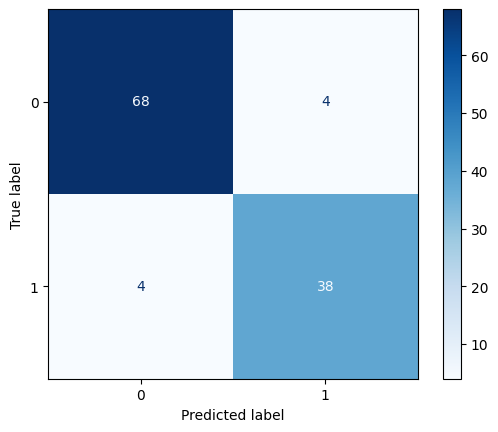

In [38]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

plt.figure(figsize=(12,9))
cm = confusion_matrix(y_test,dt_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap='Blues')
plt.show()

In [45]:
y_probs = best_dt.predict_proba(X_test)
y_probs[:,1]

array([0. , 1. , 0. , 1. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 1. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 1. , 1. , 0. ,
       0. , 1. , 1. , 1. , 1. , 0. , 1. , 1. , 0. , 0. , 0. , 0. , 1. ,
       0. , 0. , 0. , 1. , 0. , 0. , 1. , 0. , 1. , 0. , 0. , 1. , 1. ,
       0. , 0. , 0. , 1. , 0. , 0. , 0. , 1. , 0. , 0. , 1. , 0. , 0. ,
       0. , 1. , 1. , 0. , 0. , 0. , 1. , 1. , 0. , 0. , 0. , 0. , 1. ,
       0. , 1. , 1. , 1. , 0. , 0. , 0. , 0. , 1. , 1. , 1. , 0. , 1. ,
       0. , 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 1. , 0. , 1. , 0. , 0. , 0. , 0. , 1. ])

In [39]:
#ROC Curves
from sklearn.metrics import roc_curve,auc,decision_function

y_probs = best_dt.predict_proba(X_test)[:,1]
fpr,tpr,_ = roc_curve(y_test,y_probs)
roc_auc = auc(fpr,tpr)

plt.figure(figsize=(12,9))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()



ImportError: cannot import name 'decision_function' from 'sklearn.metrics' (C:\Users\evija\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\__init__.py)